<a href="https://colab.research.google.com/github/kaushikpatriot/ML-Projects/blob/main/Polynomial_Regression_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Polynomial Regression
This colab implements the polynomial regression model from scratch using the numpy library

features --> Polynomial transformation --> Linear regression --> Label

We will re-use the Linreg class that uses the Linear regression model

We will implement the polynomial transformation function

We will also implement a few helper functions for:
* Generation of training data with non-linear relationship between features and labels. We generate a single feature matrix x1 and label y

We use polynomial transformation of different degrees for modeling relationship between features and labels. Each degree results in a new polynomial model. Thus, we have multiple polynomial models from which we need to select the best performing model. We have implemented the model selection scheme towards the end of this colab.

In [ ]:
# Import libraries
from IPython.display import display, Math, Latex #Imported for proper rendering of latex in Colab
import numpy as np

#Import for generating plots
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
# [Linear Regression Class]
class LinReg(object):
  def __init__(self):
    self.t0 = 200
    self.t1 = 100000


  def predict(self, X: np.ndarray) -> np.ndarray:
    '''
    Arg: X - Feature matrix of shape (n,m+1)
        w - weight vector (m+1,n)
    Return:
        y - the predicted label (n,)
    '''
    assert X.shape[-1] == self.w.shape[0] , 'X and w do not have compatible shapes'
    return X @ self.w

  def loss(self, X: np.ndarray,y: np.ndarray) -> float:
    '''
    Args:
        X - Feature matrix
        y - label vector
        w - weight vector
    Returns:
        loss value for the given model
    '''
    e = (self.predict(X) - y)
    return (1/2)*(np.transpose(e) @ e)

  def rmse(self, X:np.ndarray, y:np.ndarray) -> float:
    '''
    Args:
        X - Feature
        y - Label
    Returns:
        Loss
    '''
    return np.sqrt((2/X.shape[0])*self.loss(X,y))

  #Normal Equation Method
  def fit(self, X: np.ndarray,y: np.ndarray) -> np.ndarray:
    '''
    Arg:
        X - Feature matrix
        y - Label vector

    Returns
        w - the weight vector
    '''
    self.w = np.linalg.pinv(X) @ y
    return self.w

  # Gradient Batch
  def calculate_gradient(self, X: np.ndarray, y: np.ndarray) -> np.ndarray:
    '''
    Args:
        X - Feature matrix
        y - Label vector
        w - weight vectors
    Returns:
        A vector of gradients
    '''
    return np.transpose(X)@(self.predict(X) - y)

  def update_weight(self, grad: np.ndarray,lr: float) -> np.ndarray:
    '''
    Args:
      w - weight vector
      grad - gradient of loss w.r.t w
      lr - learning rate
    Returns:
      Updated weight vector

    '''
    return (self.w - lr*grad)

  def learning_schedule (self,t):
    return self.t0/(t + self.t1)

  def gd(self, X:np.ndarray,y:np.ndarray,lr:float,num_epochs:int) -> np.ndarray:
    '''
    Args:
        X: Feature matrix
        y: Label vector
        lr: learning rate
        num_epochs: Number of training steps
    Returns:
        Weight vector: Final weight vector
        Error vector across different iterations
        Weight vectors across different iterations
    '''
    self.w_all = [] # All parameters across iterations
    self.err_all = [] # All errors across iterations

    #Parameter vector initialised to zero
    self.w = np.zeros((X.shape[1]))

    #Gradient descent loop
    print()
    for i in np.arange(0,num_epochs):
      self.w_all.append(self.w)

      #Calculate the error due to the current weight vector
      self.err_all.append(self.loss(X,y))

      # Gradient Calculation
      dJdW = self.calculate_gradient(X,y)

      # Print stats every 100 iterations
      if i%100 == 0:
        print('Iteration #: %d, loss: %4.2f' %(i,self.err_all[-1]))

      # Weight vector update
      self.w = self.update_weight(dJdW,lr)

      #print('Gradient - ', dJdW)
      #print('Weight -', w)

    return self.w

  #MBGD function
  def mbgd(self, X:np.ndarray, y:np.ndarray,num_iters:int,minibatch_size:int) -> np.ndarray:
    self.w_all = []
    self.err_all = []

    self.w = np.zeros((X.shape[1])) #initialise w to 0
    t = 0

    for epoch in range(num_iters):
      shuffled_indices = np.random.permutation(X.shape[0])
      X_shuffled = X[shuffled_indices]
      y_shuffled = y[shuffled_indices]
      for i in range (0,X.shape[0],minibatch_size):
        t +=1
        xi = X_shuffled[i:i+minibatch_size]
        yi = y_shuffled[i:i+minibatch_size]
        self.err_all.append(self.loss(xi,yi))

        gradients = 2/minibatch_size * self.calculate_gradient(xi,yi) # gradient scaled for MBGD & SGD
        lr = self.learning_schedule(t)

        self.w = self.update_weight(gradients, lr)
        self.w_all.append(self.w)

    return self.w

  #SGD function
  def sgd(self, X:np.ndarray, y:np.ndarray,num_epochs:int):
    self.w_all = []
    self.err_all = []

    self.w = np.zeros((X.shape[1])) #initialise w to 0
    t = 0

    for epoch in range(num_epochs):
      for i in range(X.shape[0]):
        random_index = np.random.randint(X.shape[0])
        xi = X[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        self.err_all.append(self.loss(xi,yi))

        gradients = 2 * self.calculate_gradient(xi,yi) # gradient scaled for MBGD & SGD
        lr = self.learning_schedule(epoch * X.shape[0] + i)

        self.w = self.update_weight(gradients, lr)
        self.w_all.append(self.w)

    return self.w


In [ ]:
# Generating combination of polynomials
import itertools
import functools

def get_combinations(x, degree):
  return itertools.combinations_with_replacement(x,degree)

def compute_new_features(items):
  return functools.reduce(lambda x, y: x*y, items)

In [ ]:
#Run some examples
{items: compute_new_features(items) for items in get_combinations([2,3],3)}

{(2, 2, 2): 8, (2, 2, 3): 12, (2, 3, 3): 18, (3, 3, 3): 27}

In [ ]:
#Run some examples
{items: compute_new_features(items) for items in get_combinations([2,3],3)}

{(2, 2, 2): 8, (2, 2, 3): 12, (2, 3, 3): 18, (3, 3, 3): 27}

In [ ]:
#Run some examples
{items: compute_new_features(items) for items in get_combinations([1,2,3,4,5],3)}

{(1, 1, 1): 1,
 (1, 1, 2): 2,
 (1, 1, 3): 3,
 (1, 1, 4): 4,
 (1, 1, 5): 5,
 (1, 2, 2): 4,
 (1, 2, 3): 6,
 (1, 2, 4): 8,
 (1, 2, 5): 10,
 (1, 3, 3): 9,
 (1, 3, 4): 12,
 (1, 3, 5): 15,
 (1, 4, 4): 16,
 (1, 4, 5): 20,
 (1, 5, 5): 25,
 (2, 2, 2): 8,
 (2, 2, 3): 12,
 (2, 2, 4): 16,
 (2, 2, 5): 20,
 (2, 3, 3): 18,
 (2, 3, 4): 24,
 (2, 3, 5): 30,
 (2, 4, 4): 32,
 (2, 4, 5): 40,
 (2, 5, 5): 50,
 (3, 3, 3): 27,
 (3, 3, 4): 36,
 (3, 3, 5): 45,
 (3, 4, 4): 48,
 (3, 4, 5): 60,
 (3, 5, 5): 75,
 (4, 4, 4): 64,
 (4, 4, 5): 80,
 (4, 5, 5): 100,
 (5, 5, 5): 125}

In [ ]:
#Run some examples
{items: compute_new_features(items) for items in get_combinations([4,5],1)}

{(4,): 4, (5,): 5}

In [ ]:
import numpy as np
import itertools
import functools

def polynomial_transform(x, degree, logging = False):
  # Converts to feature matrix
  if x.ndim == 1:
    x = x[:,None]

  x_t = x.transpose() # Transposes the feature matrix
  features = [np.ones(len(x))] # Populates 1s as the first feature for each example

  if logging:
    print ("Input:", x)

  for degree in range(1,degree+1):
    for items in get_combinations(x_t, degree):
      features.append(compute_new_features(items))
      if logging:
        print(items,":",compute_new_features(items))

  if logging:
    print(np.asarray(features).transpose())
  return np.asarray(features).transpose()



Lets run some examples

In [ ]:
polynomial_transform(np.array([[2,3,4],[1,2,3]]),degree=3,logging=False)

array([[ 1.,  2.,  3.,  4.,  4.,  6.,  8.,  9., 12., 16.,  8., 12., 16.,
        18., 24., 32., 27., 36., 48., 64.],
       [ 1.,  1.,  2.,  3.,  1.,  2.,  3.,  4.,  6.,  9.,  1.,  2.,  3.,
         4.,  6.,  9.,  8., 12., 18., 27.]])

In [ ]:
polynomial_transform(np.array([2,3]),degree=2,logging=True)

Input: [[2]
 [3]]
(array([2, 3]),) : [2 3]
(array([2, 3]), array([2, 3])) : [4 9]
[[1. 2. 4.]
 [1. 3. 9.]]


array([[1., 2., 4.],
       [1., 3., 9.]])

In [ ]:
polynomial_transform(np.array([[1,2],[3,4]]), degree = 2, logging = True)

Input: [[1 2]
 [3 4]]
(array([1, 3]),) : [1 3]
(array([2, 4]),) : [2 4]
(array([1, 3]), array([1, 3])) : [1 9]
(array([1, 3]), array([2, 4])) : [ 2 12]
(array([2, 4]), array([2, 4])) : [ 4 16]
[[ 1.  1.  2.  1.  2.  4.]
 [ 1.  3.  4.  9. 12. 16.]]


array([[ 1.,  1.,  2.,  1.,  2.,  4.],
       [ 1.,  3.,  4.,  9., 12., 16.]])

In [ ]:
polynomial_transform(np.array([[2,3],[4,5]]), degree = 3, logging = True)

Input: [[2 3]
 [4 5]]
(array([2, 4]),) : [2 4]
(array([3, 5]),) : [3 5]
(array([2, 4]), array([2, 4])) : [ 4 16]
(array([2, 4]), array([3, 5])) : [ 6 20]
(array([3, 5]), array([3, 5])) : [ 9 25]
(array([2, 4]), array([2, 4]), array([2, 4])) : [ 8 64]
(array([2, 4]), array([2, 4]), array([3, 5])) : [12 80]
(array([2, 4]), array([3, 5]), array([3, 5])) : [ 18 100]
(array([3, 5]), array([3, 5]), array([3, 5])) : [ 27 125]
[[  1.   2.   3.   4.   6.   9.   8.  12.  18.  27.]
 [  1.   4.   5.  16.  20.  25.  64.  80. 100. 125.]]


array([[  1.,   2.,   3.,   4.,   6.,   9.,   8.,  12.,  18.,  27.],
       [  1.,   4.,   5.,  16.,  20.,  25.,  64.,  80., 100., 125.]])

### Non-linear Training Data Generation

We generate training data with a single feature $x_1$ and label $y = sin(2πx_1) + noise$

The noise will have a gaussian distribution

In [ ]:
def create_nonlin_training_set(func,sample_size,std):
  x = np.linspace(0,1, sample_size)
  y = func(x) + np.random.normal(scale=std,size=x.shape)
  return x,y

def nonlin(x):
  return np.sin(2* np.pi* x)

##Visualizing the training data and model fitment

In [ ]:
# [Visualization]
def visualize_training_data(X_train,y_train):
  points = np.linspace(0,1,100)
  output = nonlin(points)

  plt.scatter(X_train, y_train, facecolor="none",
              edgecolor = "b", s=50, label = "training data")
  plt.plot(points, output,c="g",label = "$\sin(2\pi x)$")
  plt.xlabel('$x_1$')
  plt.ylabel('y')
  plt.legend()
  plt.show()

def visualize_model_fit(X, y, lin_reg, degree):
  '''Plots trained model alone with the data generation fucntion'''
  points = np.linspace(0, 1, 100)
  output = nonlin(points)

  if degree > 0:
      plt.scatter(X, y, facecolor="none",
              edgecolor = "b", s=50, label = "training data")

  plt.plot(points, output,c="g",label = "$\sin(2\pi x)$")
  y_hat = lin_reg.predict(polynomial_transform(points,degree))
  plt.plot(points, y_hat, c = "r", label= "$h_\mathbf{w}(x)$")
  plt.xlabel('$x_1$')
  plt.ylabel('y')
  plt.ylim(-1.5,1.5)
  plt.title("M={}".format(degree)) # xy = (-0.15,1)




We can set the number of samples required and control noise added to examples through std parameters

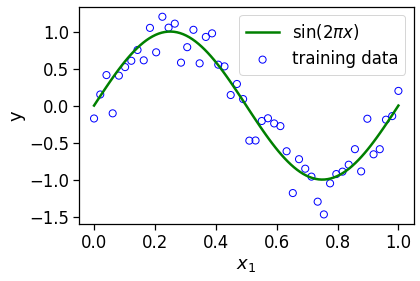

In [ ]:
#[Activity] Change the second parameter to different values
# and check the effect on the data
# try 0.001, 0.01, 0.1, 1, 10
num_samples = 50
X,y = create_nonlin_training_set(nonlin, num_samples, 0.2)
visualize_training_data(X, y)


##Polynomial Model

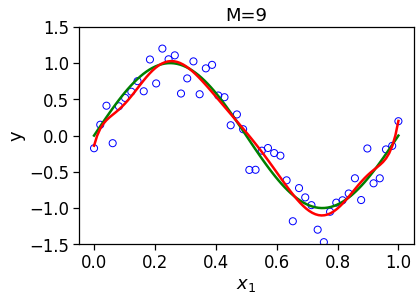

In [ ]:
#[Activity]: Change the degree here and examine the fitment
degree = 9
X_transform = polynomial_transform(X,degree)
lin_reg = LinReg()
lin_reg.fit(X_transform,y)
visualize_model_fit(X, y, lin_reg, degree)

Visualize multiple models on the same page

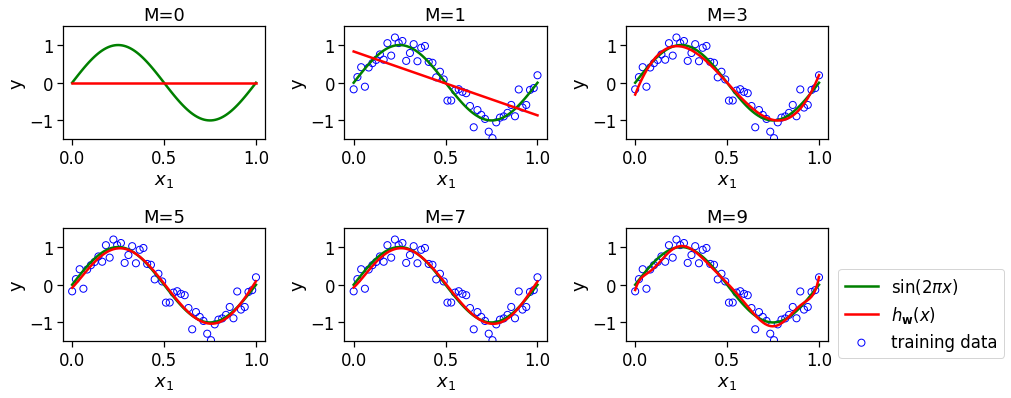

In [ ]:
f = plt.figure(figsize=(12,8))
sns.set_context("notebook",font_scale=1.5,rc= {"lines.linewidth":2.5})

for i, degree in enumerate([0, 1, 3, 5, 7, 9]):
  plt.subplot(3,3,i+1)
  X_transform = polynomial_transform(X, degree)
  lin_reg = LinReg()
  lin_reg.fit(X_transform, y)
  visualize_model_fit(X, y, lin_reg, degree)

f.tight_layout()
plt.legend(bbox_to_anchor=(1.05,0.64), loc=2, borderaxespad = 0.)
plt.show()

### Model Selection
* One polynomial model per degree. Which one to select?
* Process
  * Fix the list of degrees that you want to experiment with
  * Divide the training data into training and validation sets
  * For each degree m:
    * Train polynomial regression model with the training data
    * Calculate the training and validation errors on the trained model
* Select the model with the lowest training and validation loss among all models


In [ ]:
import pandas as pd

def convert_dict_to_df(w_dict, degree):
  poly_w_dict = {i: np.array(np.zeros(degree)) for i in range(degree)}
  for deg in poly_w_dict:
    weight_vec = w_dict[deg]
    for i in range(len(weight_vec)):
      poly_w_dict[deg][i] = weight_vec[i]

  poly_w_df = pd.DataFrame(poly_w_dict)
  poly_w_df.columns = ['w_'+str(i) for i in range(degree)]
  return poly_w_df

def plot_model_selection(training_errors, val_errors):
  plt.plot(training_errors,'o-', mfc = "none", mec = "b")
  plt.plot(val_errors,'o-', mfc= "none", mec = "r")
  plt.legend()
  plt.xlabel("degree")
  plt.ylabel("RMSE")
  plt.show()

No handles with labels found to put in legend.


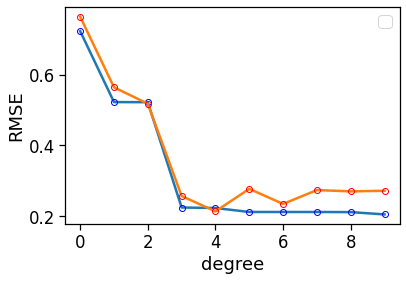

,w_0,w_1,w_2,w_3,w_4,w_5,w_6,w_7,w_8,w_9
0,-0.017676,0.829502,0.791587,-0.313514,-0.251327,-0.079904,-0.079586,-0.072058,-0.047778,-0.139669
1,0.000000,-1.694355,-1.462128,12.509372,11.141052,5.156824,5.140155,4.566286,1.922936,16.112705
2,0.000000,0.000000,-0.232227,-35.516118,-29.212743,14.374711,14.551482,22.944567,74.227272,-280.245218
3,0.000000,0.000000,0.000000,23.522594,13.652485,-104.283505,-105.007500,-153.227852,-546.220396,2947.436502
4,0.000000,0.000000,0.000000,0.000000,4.935055,138.251586,139.623055,274.387038,1781.281891,-15739.462523
5,0.000000,0.000000,0.000000,0.000000,0.000000,-53.326612,-54.537979,-250.096652,-3421.694132,46421.682413
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.403789,142.056868,3864.454667,-79957.060666
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-40.472308,-2324.928284,80176.128316
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,571.113994,-43342.925171
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9758.675370


In [ ]:
training_errors = []
val_errors = []
w_dict = {}

X_val = np.linspace(0,1,100)
y_val = nonlin(X_val)

for i in range(10):
  X_transform = polynomial_transform(X,i)
  X_val_transform = polynomial_transform(X_val, i)
  lin_reg = LinReg()
  lin_reg.fit(X_transform, y)

  w_dict[i] = lin_reg.w
  training_errors.append(lin_reg.rmse(X_transform, y))
  val_errors.append(lin_reg.rmse(X_val_transform, y_val+np.random.normal(scale=0.25, size = len(y_val))))

plot_model_selection(training_errors, val_errors)
convert_dict_to_df(w_dict,10)


##Ridge and Lasso Regularization
We implement ridge regularization from scratch and use sklearn library fro Lasso regularization

Polynomial regression is able to fit non-linear relationship between features and labels. However, higher order polynomial models are prone to overfitting. There are two ways to tackle the problem of overfitting:
1. Train with more data
2. Penalize the weight vector through regularization

In this section, we will focus on point #2
* Regularization leads to change in the Linear Regression Loss function, which inturn results in change in gradient calculation
* We plan to demonstrate the use of regularization with polynomial regression model and synthetically generated non-linear data set

The change in regularization rate results in a new model. For different values of regularization weights, we obtain a new model. Thus have a problem of model selection at hand, where we need to choose the best model among the list of candidate models.

Finally, we will demonstrate ridge and lasso solution path as a function of regularization rate $\lambda$

### Ridge Regularization
We will implement ridge regression by making the following changes to Linear regression model
1. Loss function: $J(w) = \frac 1 2 (Xw-y)^T(Xw-y) + \frac \lambda  2 w^Tw$

2. Gradient Calculation (calculate_gradient): $\frac {\partial J(w)} {\partial w} = X^T(Xw-y)+\lambda w $

3. Normal Equation (fit): $w = (X^TX + \lambda I) ^{-1} X^Ty$  

In [ ]:
# [Linear Regression Class] - Modified for Regularization
class LinReg(object):
  def __init__(self):
    self.t0 = 200
    self.t1 = 100000


  def predict(self, X: np.ndarray) -> np.ndarray:
    '''
    Arg: X - Feature matrix of shape (n,m+1)
        w - weight vector (m+1,n)
    Return:
        y - the predicted label (n,)
    '''
    assert X.shape[-1] == self.w.shape[0] , 'X and w do not have compatible shapes'
    return X @ self.w

  def loss(self, X: np.ndarray,y: np.ndarray, reg_rate:float) -> float:
    '''
    Args:
        X - Feature matrix
        y - label vector
        w - weight vector
    Returns:
        loss value for the given model
    '''
    e = (self.predict(X) - y)
    return (1/2)*(np.transpose(e) @ e) + (reg_rate/2)* (np.transpose(self.w) @ self.w)

  def rmse(self, X:np.ndarray, y:np.ndarray) -> float:
    '''
    Args:
        X - Feature
        y - Label
    Returns:
        Loss
    '''
    return np.sqrt((2/X.shape[0])*self.loss(X,y,0))

  #Normal Equation Method
  def fit(self, X: np.ndarray,y: np.ndarray, reg_rate:float) -> np.ndarray:
    '''
    Arg:
        X - Feature matrix
        y - Label vector

    Returns
        w - the weight vector
    '''
    self.w = np.zeros((X.shape[1]))
    eye = np.eye(np.size(X,1))
    self.w = np.linalg.solve(reg_rate*eye + np.transpose(X) @ X,
                             np.transpose(X) @ y)
    return self.w

  # Gradient Batch
  def calculate_gradient(self, X: np.ndarray, y: np.ndarray, reg_rate:float) -> np.ndarray:
    '''
    Args:
        X - Feature matrix
        y - Label vector
        w - weight vectors
    Returns:
        A vector of gradients
    '''
    return np.transpose(X)@(self.predict(X) - y) + reg_rate*self.w

  def update_weight(self, grad: np.ndarray,lr: float) -> np.ndarray:
    '''
    Args:
      w - weight vector
      grad - gradient of loss w.r.t w
      lr - learning rate
    Returns:
      Updated weight vector

    '''
    return (self.w - lr*grad)

  def learning_schedule (self,t):
    return self.t0/(t + self.t1)

  def gd(self, X:np.ndarray,y:np.ndarray,lr:float,num_epochs:int, reg_rate:float) -> np.ndarray:
    '''
    Args:
        X: Feature matrix
        y: Label vector
        lr: learning rate
        num_epochs: Number of training steps
    Returns:
        Weight vector: Final weight vector
        Error vector across different iterations
        Weight vectors across different iterations
    '''
    self.w_all = [] # All parameters across iterations
    self.err_all = [] # All errors across iterations

    #Parameter vector initialised to zero
    self.w = np.zeros((X.shape[1]))

    #Gradient descent loop
    print()
    for i in np.arange(0,num_epochs):
      self.w_all.append(self.w)

      #Calculate the error due to the current weight vector
      self.err_all.append(self.loss(X,y,reg_rate))

      # Gradient Calculation
      dJdW = self.calculate_gradient(X,y, reg_rate)

      # Print stats every 100 iterations
      if i%100 == 0:
        print('Iteration #: %d, loss: %4.2f' %(i,self.err_all[-1]))

      # Weight vector update
      self.w = self.update_weight(dJdW,lr)

      #print('Gradient - ', dJdW)
      #print('Weight -', w)

    return self.w

  #MBGD function
  def mbgd(self, X:np.ndarray, y:np.ndarray,num_iters:int,minibatch_size:int, reg_rate:float) -> np.ndarray:
    self.w_all = []
    self.err_all = []

    self.w = np.zeros((X.shape[1])) #initialise w to 0
    t = 0

    for epoch in range(num_iters):
      shuffled_indices = np.random.permutation(X.shape[0])
      X_shuffled = X[shuffled_indices]
      y_shuffled = y[shuffled_indices]
      for i in range (0,X.shape[0],minibatch_size):
        t +=1
        xi = X_shuffled[i:i+minibatch_size]
        yi = y_shuffled[i:i+minibatch_size]
        self.err_all.append(self.loss(xi,yi,reg_rate))

        gradients = 2/minibatch_size * self.calculate_gradient(xi,yi, reg_rate) # gradient scaled for MBGD & SGD
        lr = self.learning_schedule(t)

        self.w = self.update_weight(gradients, lr)
        self.w_all.append(self.w)

    return self.w

  #SGD function
  def sgd(self, X:np.ndarray, y:np.ndarray,num_epochs:int, reg_rate:float):
    self.w_all = []
    self.err_all = []

    self.w = np.zeros((X.shape[1])) #initialise w to 0
    t = 0

    for epoch in range(num_epochs):
      for i in range(X.shape[0]):
        random_index = np.random.randint(X.shape[0])
        xi = X[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        self.err_all.append(self.loss(xi,yi,reg_rate))

        gradients = 2 * self.calculate_gradient(xi,yi, reg_rate) # gradient scaled for MBGD & SGD
        lr = self.learning_schedule(epoch * X.shape[0] + i)

        self.w = self.update_weight(gradients, lr)
        self.w_all.append(self.w)

    return self.w


In [ ]:
import unittest

class TestLossFunction(unittest.TestCase):
  def test_loss_function(self):
    #set up
    feature_matrix = np.array([[1,3,2,5],[1,9,4,7]])
    weight_vector = np.array([1,1,1,1])
    label_vector = np.array([6,11])
    reg_rate = 0.01
    expected_loss = np.array([62.52])

    #call
    lin_reg = LinReg()
    lin_reg.w = weight_vector
    loss_value = lin_reg.loss(feature_matrix, label_vector, reg_rate)

    #test the shape
    self.assertEqual(loss_value.shape, ())

    #test the content
    np.testing.assert_array_equal(expected_loss, loss_value)

unittest.main(argv = [''], defaultTest = 'TestLossFunction', verbosity = 2, exit = False )

test_loss_function (__main__.TestLossFunction) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.008s

OK


In [ ]:
import unittest

class TestCalculateGradient(unittest.TestCase):
  def test_calculate_gradient(self):
    #set up
    feature_matrix = np.array([[1,3,2,5],[1,9,4,7]])
    weight_vector = np.array([1,1,1,1])
    label_vector = np.array([6,11])
    reg_rate = 0.01
    expected_grad = np.array([15.01,105.01,50.01,95.01])

    #call
    lin_reg = LinReg()
    lin_reg.w = weight_vector
    grad = lin_reg.calculate_gradient(feature_matrix, label_vector, reg_rate)

    #test the shape
    self.assertEqual(grad.shape, (4, ))

    #test the content
    np.testing.assert_array_equal(expected_grad, grad)

unittest.main(argv = [''], defaultTest = 'TestCalculateGradient', verbosity = 2, exit = False )

test_calculate_gradient (__main__.TestCalculateGradient) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.005s

OK


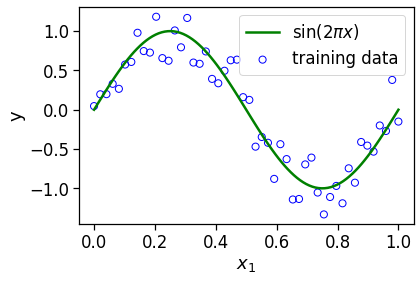

In [ ]:
#[Activity] Change the second parameter to different values
# and check the effect on the data
# try 0.001, 0.01, 0.1, 1, 10
num_samples = 50
X,y = create_nonlin_training_set(nonlin, num_samples, 0.2)
visualize_training_data(X, y)


In [ ]:
# [Visualization]
def visualize_training_data(X_train,y_train):
  points = np.linspace(0,1,100)
  output = nonlin(points)

  plt.scatter(X_train, y_train, facecolor="none",
              edgecolor = "b", s=50, label = "training data")
  plt.plot(points, output,c="g",label = "$\sin(2\pi x)$")
  plt.xlabel('$x_1$')
  plt.ylabel('y')
  plt.legend()
  plt.show()

def visualize_model_fit(X, y, lin_reg, degree, reg_rate):
  '''Plots trained model alone with the data generation fucntion'''
  points = np.linspace(0, 1, 100)
  output = nonlin(points)

  if degree > 0:
      plt.scatter(X, y, facecolor="none",
              edgecolor = "b", s=50, label = "training data")

  plt.plot(points, output,c="g",label = "$\sin(2\pi x)$")
  y_hat = lin_reg.predict(polynomial_transform(points,degree))
  plt.plot(points, y_hat, c = "r", label= "$h_\mathbf{w}(x)$")
  plt.xlabel('$x_1$')
  plt.ylabel('y')
  plt.ylim(-1.5,1.5)
  plt.title("M={}".format(degree)+" $\lambda$={}".format(reg_rate)) # xy = (-0.15,1)




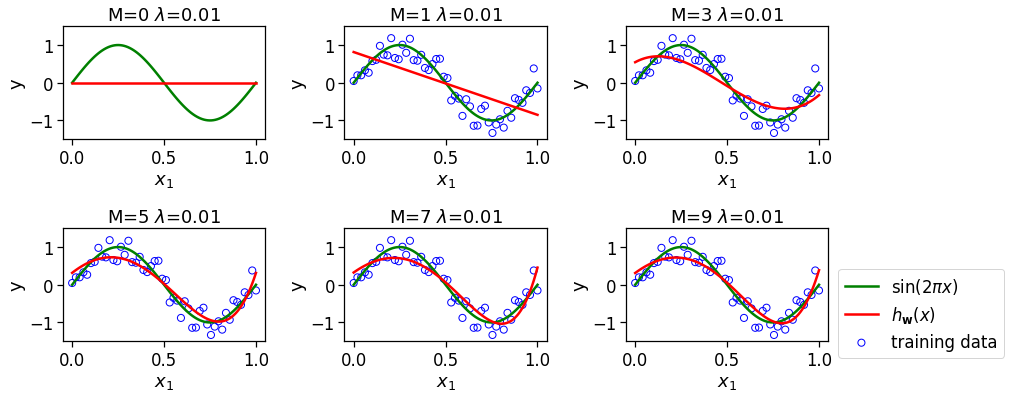

In [ ]:
f = plt.figure(figsize=(12,8))
sns.set_context("notebook",font_scale=1.5,rc= {"lines.linewidth":2.5})

for i, degree in enumerate([0, 1, 3, 5, 7, 9]):
  plt.subplot(3,3,i+1)
  X_transform = polynomial_transform(X, degree)
  lin_reg = LinReg()
  lin_reg.fit(X_transform, y, reg_rate = 0.01)
  visualize_model_fit(X, y, lin_reg, degree, reg_rate = 0.01)

f.tight_layout()
plt.legend(bbox_to_anchor=(1.05,0.64), loc=2, borderaxespad = 0.)
plt.show()

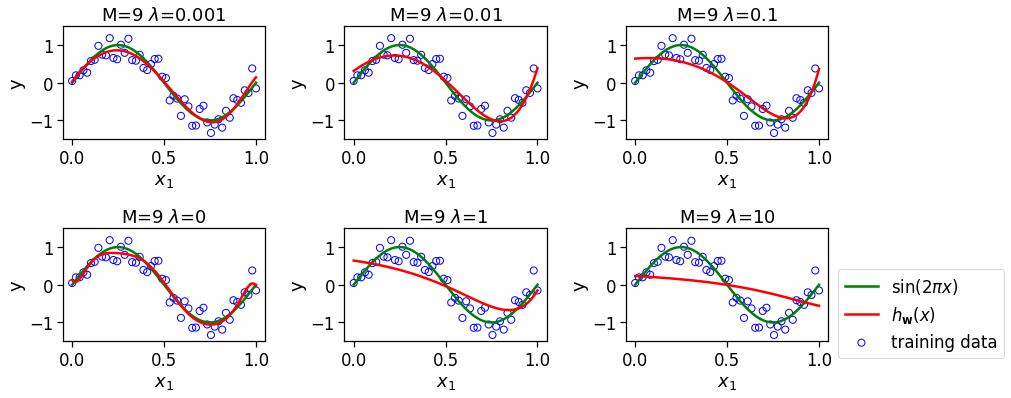

In [ ]:
f = plt.figure(figsize=(12,8))
sns.set_context("notebook",font_scale=1.5,rc= {"lines.linewidth":2.5})
degree = 9

for i, reg_rate in enumerate([1e-3,1e-2,1e-1,0,1,10]):
  plt.subplot(3,3,i+1)
  X_transform = polynomial_transform(X, degree)
  lin_reg = LinReg()
  lin_reg.fit(X_transform, y, reg_rate)
  visualize_model_fit(X, y, lin_reg, degree, reg_rate)

f.tight_layout()
plt.legend(bbox_to_anchor=(1.05,0.64), loc=2, borderaxespad = 0.)
plt.show()

###Model Selection
* One model per $\lambda$
* Process
  * Fix the list of $\lambda$ that you want to experiment with
  * Divide the data into training, test and validation sets
  * For each $\lambda$
    * Training ridge regression model with $\lambda$ for training data
    * Calculate training and validation errors on the trained model
* Select the model with the lowest training and validation loss among all models

In [ ]:
def plot_reg_w(w_df):
  ax = plt.gca()
  ax.plot(w_df.T)
  ax.set_xscale('log')
  ax.set_xlim(ax.get_xlim()[::-1])
  plt.xlabel('$\lambda$')
  plt.ylabel('$\mathbf{w}$')
  plt.title('Weights as a function of $\lambda$')
  plt.axis('tight')
  plt.show()

def plot_learning_curve(err_df):
  ax = plt.gca()
  ax.plot(err_df)
  ax.set_xscale('log')
  ax.set_xlim(ax.get_xlim()[::-1])
  plt.xlabel('$\lambda$')
  plt.ylabel('RMSE')
  plt.title('Training and validation losses as a function of $\lambda$')
  plt.axis('tight')
  plt.legend(['training','validation'])
  plt.show()




In [ ]:
import pandas as pd

training_errors = {}
val_errors = {}
w_dict = {}
degree = 9

X_val = np.linspace(0,1,100)
y_val = nonlin(X_val)

X_transform = polynomial_transform(X, degree)
X_val_transform = polynomial_transform(X_val,degree)

for reg_rate in [1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1,10,100]:
  lin_reg = LinReg()
  lin_reg.fit(X_transform,y, reg_rate)

  w_dict[reg_rate] = lin_reg.w
  training_errors[reg_rate] = lin_reg.rmse(X_transform,y)
  val_errors[reg_rate] = lin_reg.rmse(X_val_transform, y_val
                                     + np.random.normal(scale=0.25,size = len(y_val)))
err_df = pd.DataFrame([training_errors,val_errors]).T
w_df = pd.DataFrame(w_dict)


Lets plot learning curves with $\lambda$ on x-axis and RMSE on y-axis

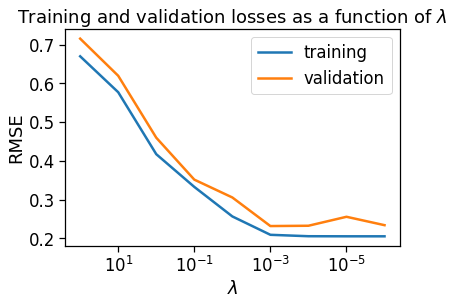

In [ ]:
plot_learning_curve(err_df)

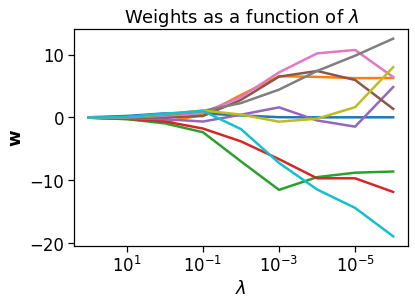

In [ ]:
plot_reg_w(w_df)

##Lasso Regression

Lasso uses $L_1$ norm of weight vector instead of $L_2$ as used in the ridge regression.

Lasso does not have closed form solution and its loss function is not differentiable at all points. We need to use specialised algorithm to learn lasso paramters. We will use *sklearn* Lasso implementation

In [ ]:
from sklearn.linear_model import Lasso

#Lasso
reg_rate = 0.01
lasso = Lasso(alpha=reg_rate)
lasso.fit(X_transform, y)

#Linear regression
lin_reg = LinReg()
_ = lin_reg.fit(X_transform, y, 0)

Lets compare weight vectors of linear, ridge and lasso regression.

In [ ]:
pd.DataFrame({'LinReg': lin_reg.w, 'Ridge': w_df[0.01], 'Lasso':lasso.coef_})

,LinReg,Ridge,Lasso
0,0.123661,0.312235,0.000000
1,-7.745897,3.576236,-0.000000
2,309.598264,-7.000425,-2.683590
3,-2946.786580,-3.818266,-0.000000
4,14007.616614,0.425893,-0.000000
5,-38315.911299,2.792169,0.000000
6,62475.554465,3.232681,0.000000
7,-59938.914802,2.280333,0.000000
8,31259.757988,0.452382,0.000000
9,-6843.327283,-1.865712,2.082074


###Observations
1. Lasso obtains a sparse feature vector. Many 0 coefficients or weights
2. Ridge regression assigns small weights to each feature

A couple of points about using Lasso and Ridge:
* Lasso is used for feature selection
  * When all features are useful for making prediction about the output, we use ridge regression. It produces a weight vector with small non-zero values to all features.
  * When a few features are useful for making predictions, we use lasso. It produces a weight vector that assigns 0 weights to unimportant features.

Lets visualise models learnt by three models

Text(0.5, 1.0, 'Lasso (M=9, $\\lambda=0$')

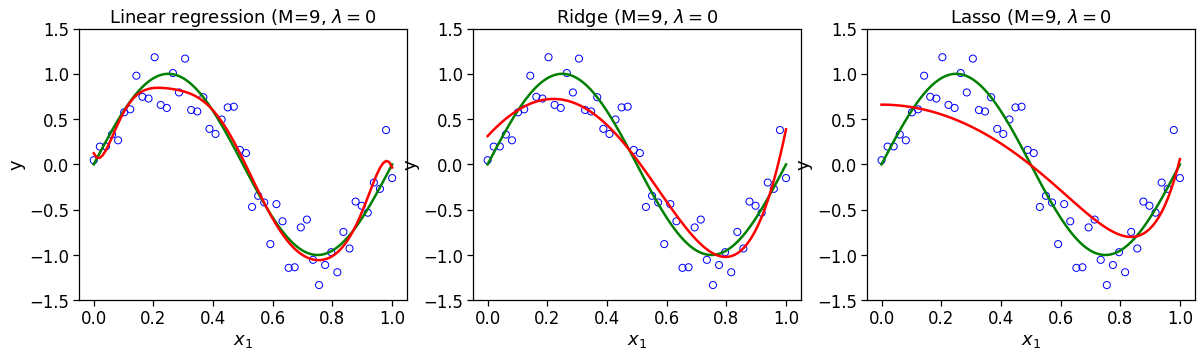

In [ ]:
f = plt.figure(figsize=(20,5))
axl = plt.subplot(1,3,1)
visualize_model_fit(X, y, lin_reg, degree, reg_rate = 0)
plt.title('Linear regression (M=9, $\lambda=0$')

lin_reg.w = w_df[0.01]
ax2 = plt.subplot(1,3,2)
visualize_model_fit(X, y, lin_reg, degree, reg_rate = 0.01)
plt.title('Ridge (M=9, $\lambda=0$')

ax2 = plt.subplot(1,3,3)
visualize_model_fit(X, y, lasso, degree, reg_rate = 0.01)
plt.title('Lasso (M=9, $\lambda=0$')


/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.022e-02, tolerance: 2.498e-03
  coef_, l1_reg, l2_reg, X, y, max_iter, tol, rng, random, positive
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:9: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  if __name__ == '__main__':
/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_coordinate_descent.py:648: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  coef_, l1_reg, l2_reg, X, y, max_iter, tol, rng, random, positive
/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want t

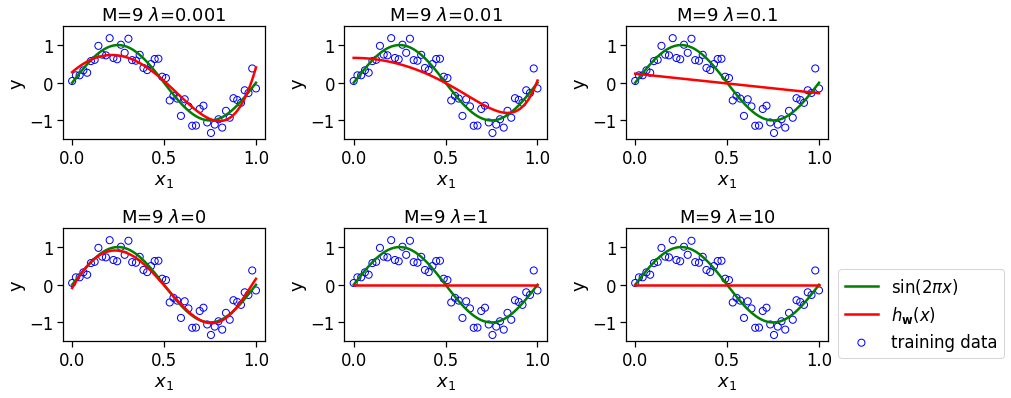

In [ ]:
f = plt.figure(figsize=(12,8))
sns.set_context("notebook",font_scale=1.5,rc= {"lines.linewidth":2.5})
degree = 9
X_transform = polynomial_transform(X, degree)

for i, reg_rate in enumerate([1e-3,1e-2,1e-1,0,1,10]):
  plt.subplot(3,3,i+1)
  lasso = Lasso(alpha=reg_rate)
  lasso.fit(X_transform, y)
  visualize_model_fit(X, y, lasso, degree, reg_rate)

f.tight_layout()
plt.legend(bbox_to_anchor=(1.05,0.64), loc=2, borderaxespad = 0.)
plt.show()

###Model Selection

In [ ]:
import pandas as pd
from sklearn.metrics import mean_squared_error

training_errors = {}
val_errors = {}
w_dict = {}
degree = 9

X_val = np.linspace(0,1,100)
y_val = nonlin(X_val)

X_transform = polynomial_transform(X, degree)
X_val_transform = polynomial_transform(X_val,degree)

for reg_rate in [1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1,10,100]:
  lasso = Lasso(alpha=reg_rate)
  lasso.fit(X_transform,y)

  w_dict[reg_rate] = lasso.coef_
  training_errors[reg_rate] = mean_squared_error(y, lasso.predict(X_transform), squared=False)
  val_errors[reg_rate] = mean_squared_error(y_val + np.random.normal(scale=0.25,size = len(y_val)),
                                     lasso.predict(X_val_transform), squared=False)
err_df = pd.DataFrame([training_errors,val_errors]).T
w_df = pd.DataFrame(w_dict)


/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.122e+00, tolerance: 2.498e-03
  coef_, l1_reg, l2_reg, X, y, max_iter, tol, rng, random, positive
/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.023e+00, tolerance: 2.498e-03
  coef_, l1_reg, l2_reg, X, y, max_iter, tol, rng, random, positive
/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisa

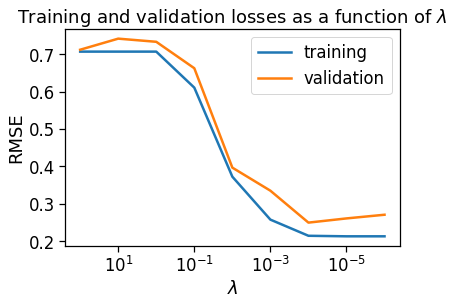

In [ ]:
plot_learning_curve(err_df)

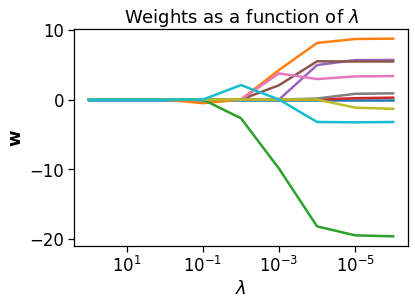

In [ ]:
plot_reg_w(w_df)

##Multi-output / Multi-label Regression

In case of multi-output regression, there are more than one output labels, all of which are real numbers

### Training Data
$ D = (X,Y) = {(x^{(i)},y^{(i)})}^n_i = 0$

Here: $y^{(i)} = R^k$ where $k$ is the number of output labels. In simple terms, $y^{(i)}$ has $k$ components that are real numbers

Let's generate synthetic data for demonstrating the training set in multi-ouput regression using *make_regression* dataset generation function from sklearn library

In [ ]:
from sklearn.datasets import make_regression
X, y, coef = make_regression(n_samples = 100, n_features = 10, n_informative=10,
                             bias = 1, n_targets = 5, shuffle=True, coef=True, random_state = 42)

In [ ]:
#Lets check the shapes
print (X.shape)
print (y.shape)

(100, 10)
(100, 5)


In [ ]:
print ("Sample training examples: \n", X[:5])
print ("Corresponding labels: \n", y[:5])

Sample training examples: 
 [[-2.07339023 -0.37144087  1.27155509  1.75227044  0.93567839 -1.40751169
  -0.77781669 -0.34268759 -1.11057585  1.24608519]
 [-0.90938745 -1.40185106 -0.50347565 -0.56629773  0.09965137  0.58685709
   2.19045563  1.40279431 -0.99053633  0.79103195]
 [-0.18565898 -1.19620662 -0.64511975  1.0035329   0.36163603  0.81252582
   1.35624003 -1.10633497 -0.07201012 -0.47917424]
 [ 0.03526355  0.21397991 -0.57581824  0.75750771 -0.53050115 -0.11232805
  -0.2209696  -0.69972551  0.6141667   1.96472513]
 [-0.51604473 -0.46227529 -0.8946073  -0.47874862  1.25575613 -0.43449623
  -0.30917212  0.09612078  0.22213377  0.93828381]]
Corresponding labels: 
 [[-133.15919852  -88.95797818   98.19127175   25.68295511 -132.79294654]
 [-110.38909784  146.04459736 -169.58916067  118.96066861 -177.08414159]
 [ -97.80350267    4.32654061  -87.56082281   -5.58466452    6.36897388]
 [  25.39024616  -70.41180117  186.15213706  132.77153362   53.42301307]
 [-140.61925153  -53.87007831 

In [ ]:
coef

array([[93.62122462,  5.19712837, 54.12963353, 70.90605195, 87.09691237],
       [89.48166561, 54.75923762, 81.729777  , 45.23182845, 64.35776952],
       [46.26229567, 86.82725054, 72.71690698, 74.27065212, 42.54933344],
       [71.92017783, 22.84547413, 99.63339161, 97.47931621, 65.03256863],
       [19.95424509, 68.02282424,  7.2198409 ,  3.06525022, 25.76828885],
       [52.64026609, 73.15895218,  8.1629982 ,  6.0352084 , 24.7103234 ],
       [15.95446801, 87.17835666, 21.92139874, 97.58652558, 33.68957918],
       [71.40869321, 80.17280831, 33.94501925, 81.48251137,  8.01148464],
       [18.21179157, 78.96985071, 65.87077755, 49.81957165, 55.53635509],
       [16.74825823, 10.45678403, 63.64302495, 70.64757265,  3.15861448]])

In [ ]:
def preprocess(X,y):
  from sklearn.model_selection import train_test_split
  X_train, X_test, y_train,  y_test = train_test_split(X,y,test_size = 0.20, random_state = 42)
  return X_train, X_test, y_train, y_test

#X_train, X_test, y_train,  y_test = preprocess(X,y)

In [ ]:
X_train, X_test, y_train, y_test = preprocess(X,y)

In [ ]:
def add_dummy_feature(x):
  ''' Adds a dummy feature to the dataset

  Args:
    x: Training Dataset

  Returns:
    Training dataset with the addition of the dummy feature
  '''
  #np.ones(x.shape(0)) creates a vector of 1s having the same rows as number of samples in dataset
  return np.column_stack((np.ones(x.shape[0]),x))

In [ ]:
print ('Before adding the dummy feature:\n', X_train[:5])
print ('\n')

X_train = add_dummy_feature(X_train)

print ('After adding the dummy feature:\n', X_train[:5,:])

Before adding the dummy feature:
 [[-0.54685894 -0.54342477  1.09150685  1.50399299 -2.65096981 -0.71284578
   0.10643023 -0.03275327 -0.25497722 -0.57366201]
 [-0.89725437 -0.67716171 -0.56372455 -0.32138584  0.41293145  0.97511973
  -0.14705738  0.07580456 -0.8254972  -0.01224677]
 [ 0.59515703  2.09238728  0.62834551  0.79166269  0.62411982 -1.00601738
  -1.21418861 -0.81822068  1.15811087  0.09699596]
 [-0.42064532 -0.80227727 -0.07444592  0.17457781  0.25755039 -0.16128571
   0.40405086 -0.34271452  1.8861859  -1.41537074]
 [-1.12905177  0.48937456  0.44426331 -0.37482081  0.71095997 -1.22212781
   0.71299843 -0.52452027 -0.2403254   0.72167206]]


After adding the dummy feature:
 [[ 1.         -0.54685894 -0.54342477  1.09150685  1.50399299 -2.65096981
  -0.71284578  0.10643023 -0.03275327 -0.25497722 -0.57366201]
 [ 1.         -0.89725437 -0.67716171 -0.56372455 -0.32138584  0.41293145
   0.97511973 -0.14705738  0.07580456 -0.8254972  -0.01224677]
 [ 1.          0.59515703  2.09

###Model
The linear regression model is exactly the same as a single label output except that the output is now a vector.

$Y_{n \times k} = X_{n \times (m+1)} W _ {(m+1) \times k}$

In this equation, the output label is a matrix Y. In order to generate multiple outputs, we need one weight vector per output. Hence, total of k vectors corresponding to k outputs.

There are two options for modelling this problem:
1. Solve k independent linear regression problems. Gives some flexibility in using different representation for each problem

2. Solve a joint learning problem as outlined in the equation above. We would pursue this approach in this colab

###Loss

$J(W) = \frac 1 2 (XW - Y)^T (XW-Y)$

Note $W$ and $Y$ are matrix now and not just vectors

###Optimization
1. Normal Equation
2. Gradient Descent and its variation

###Evaluation
1. RMSE or Loss

###Linear Regression function for multi output label

In [ ]:
# [Linear Regression Class] - Modified for Regularization and Multi Output Label
class LinReg(object):
  def __init__(self):
    self.t0 = 200
    self.t1 = 100000


  def predict(self, X: np.ndarray) -> np.ndarray:
    '''
    Arg: X - Feature matrix of shape (n,m+1)
        w - weight vector (m+1,n)
    Return:
        y - the predicted label (n,)
    '''
    assert X.shape[-1] == self.w.shape[0] , 'X and w do not have compatible shapes'
    return X @ self.w

  def loss(self, X: np.ndarray,y: np.ndarray, reg_rate:float) -> float:
    '''
    Args:
        X - Feature matrix
        y - label vector
        w - weight vector
    Returns:
        loss value for the given model
    '''
    e = (self.predict(X) - y)
    return (1/2)*(np.transpose(e) @ e) + (reg_rate/2)* (np.transpose(self.w) @ self.w)

  def rmse(self, X:np.ndarray, y:np.ndarray) -> float:
    '''
    Args:
        X - Feature
        y - Label
    Returns:
        Loss
    '''
    return np.sqrt((2/X.shape[0])*self.loss(X,y,0))

  #Normal Equation Method
  def fit(self, X: np.ndarray,y: np.ndarray, reg_rate:float) -> np.ndarray:
    '''
    Arg:
        X - Feature matrix
        y - Label vector

    Returns
        w - the weight vector
    '''
    self.w = np.zeros((X.shape[1], y.shape[1]))
    eye = np.eye(np.size(X,1))
    self.w = np.linalg.solve(reg_rate*eye + np.transpose(X) @ X,
                             np.transpose(X) @ y)
    return self.w

  # Gradient Batch
  def calculate_gradient(self, X: np.ndarray, y: np.ndarray, reg_rate:float) -> np.ndarray:
    '''
    Args:
        X - Feature matrix
        y - Label vector
        w - weight vectors
    Returns:
        A vector of gradients
    '''
    return np.transpose(X)@(self.predict(X) - y) + reg_rate*self.w

  def update_weight(self, grad: np.ndarray,lr: float) -> np.ndarray:
    '''
    Args:
      w - weight vector
      grad - gradient of loss w.r.t w
      lr - learning rate
    Returns:
      Updated weight vector

    '''
    return (self.w - lr*grad)

  def learning_schedule (self,t):
    return self.t0/(t + self.t1)

  def gd(self, X:np.ndarray,y:np.ndarray,lr:float,num_epochs:int, reg_rate:float) -> np.ndarray:
    '''
    Args:
        X: Feature matrix
        y: Label vector
        lr: learning rate
        num_epochs: Number of training steps
    Returns:
        Weight vector: Final weight vector
        Error vector across different iterations
        Weight vectors across different iterations
    '''
    self.w_all = [] # All parameters across iterations
    self.err_all = [] # All errors across iterations

    #Parameter vector initialised to zero
    self.w = np.zeros((X.shape[1],y.shape[1]))

    #Gradient descent loop
    print()
    for i in np.arange(0,num_epochs):
      self.w_all.append(self.w)

      #Calculate the error due to the current weight vector
      self.err_all.append(self.loss(X,y,reg_rate))

      # Gradient Calculation
      dJdW = self.calculate_gradient(X,y, reg_rate)

      # Print stats every 100 iterations
      if i%100 == 0:
        print('Iteration #: %d, loss: %4.2f' %(i,self.err_all[-1]))

      # Weight vector update
      self.w = self.update_weight(dJdW,lr)

      #print('Gradient - ', dJdW)
      #print('Weight -', w)

    return self.w

  #MBGD function
  def mbgd(self, X:np.ndarray, y:np.ndarray,num_iters:int,minibatch_size:int, reg_rate:float) -> np.ndarray:
    self.w_all = []
    self.err_all = []

    self.w = np.zeros((X.shape[1])) #initialise w to 0
    t = 0

    for epoch in range(num_iters):
      shuffled_indices = np.random.permutation(X.shape[0])
      X_shuffled = X[shuffled_indices]
      y_shuffled = y[shuffled_indices]
      for i in range (0,X.shape[0],minibatch_size):
        t +=1
        xi = X_shuffled[i:i+minibatch_size]
        yi = y_shuffled[i:i+minibatch_size]
        self.err_all.append(self.loss(xi,yi,reg_rate))

        gradients = 2/minibatch_size * self.calculate_gradient(xi,yi, reg_rate) # gradient scaled for MBGD & SGD
        lr = self.learning_schedule(t)

        self.w = self.update_weight(gradients, lr)
        self.w_all.append(self.w)

    return self.w

  #SGD function
  def sgd(self, X:np.ndarray, y:np.ndarray,num_epochs:int, reg_rate:float):
    self.w_all = []
    self.err_all = []

    self.w = np.zeros((X.shape[1])) #initialise w to 0
    t = 0

    for epoch in range(num_epochs):
      for i in range(X.shape[0]):
        random_index = np.random.randint(X.shape[0])
        xi = X[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        self.err_all.append(self.loss(xi,yi,reg_rate))

        gradients = 2 * self.calculate_gradient(xi,yi, reg_rate) # gradient scaled for MBGD & SGD
        lr = self.learning_schedule(epoch * X.shape[0] + i)

        self.w = self.update_weight(gradients, lr)
        self.w_all.append(self.w)

    return self.w


In [ ]:
lin_reg = LinReg()
w = lin_reg.fit(X_train , y_train, reg_rate = 0)

#Check if the weight vector is same as the co-efficient vector used for making the data
np.testing.assert_almost_equal(w[1:,:], coef, decimal = 2)

NameError: ignored

In [ ]:
w

array([[ 1.        ,  1.        ,  1.        ,  1.        ,  1.        ],
       [93.62122462,  5.19712837, 54.12963353, 70.90605195, 87.09691237],
       [89.48166561, 54.75923762, 81.729777  , 45.23182845, 64.35776952],
       [46.26229567, 86.82725054, 72.71690698, 74.27065212, 42.54933344],
       [71.92017783, 22.84547413, 99.63339161, 97.47931621, 65.03256863],
       [19.95424509, 68.02282424,  7.2198409 ,  3.06525022, 25.76828885],
       [52.64026609, 73.15895218,  8.1629982 ,  6.0352084 , 24.7103234 ],
       [15.95446801, 87.17835666, 21.92139874, 97.58652558, 33.68957918],
       [71.40869321, 80.17280831, 33.94501925, 81.48251137,  8.01148464],
       [18.21179157, 78.96985071, 65.87077755, 49.81957165, 55.53635509],
       [16.74825823, 10.45678403, 63.64302495, 70.64757265,  3.15861448]])

In [ ]:
w = lin_reg.gd(X_train, y_train, num_epochs=100, lr=0.01, reg_rate=0)
np.testing.assert_almost_equal(w[1:,:], coef, decimal = 2)

NameError: ignored

In [ ]:
import numpy as np
X = np.array([[1,1,2,3],[1,3,2,4]])
w_1 = np.array([1,0.1,-0.2,0.3])
y = np.array([2,4])
w_2 = np.array([1,0.01,-0.5,0])


e =X@w_1-y
Loss_ridge = 0.5*(e.T@e) + (0.1/2)*(w_1.T@w_1)
print(Loss_ridge)

e =X@w_2-y
Loss_lasso = 0.5*e.T@e #+ (0.1/2)*sum(np.absolute(w_2))
print(Loss_lasso)

1.885
1.885
9.8605


In [ ]:
import numpy as np
a = np.empty((20,))
a[::2] = 0
a[1::2] = 1

a.shape[0]



20